CS343: Neural Networks

Oliver W. Layton

Fall 2025

In [1]:
import numpy as np

# Scientific Computing Tutorial

Review of some:
- numpy
- matplotlib
- pandas

concepts important for neural networks.

## 1: Numpy ndarray data type

- In this class we will **only** use Numpy's ndarray data type (`np.array()`), NOT `np.matrix`.
- Matrix is deprecated (being phased out). Scientific computing / machine learning / neural network libraries assume that you are working with ndarray.

### We can make a 2D ndarray several ways

#### 1) Pass in 2D python list in contructor

Example: matrix with 1 row and 2 columns (**row vector**)

In [2]:
ar2 = np.array([[22, 33]])
print(ar2)
ar2.shape

[[22 33]]


(1, 2)

#### 2) Create singleton dimension with `np.newaxis`

In [5]:
ar2 = np.array([22, 23])
print(ar2)
ar2 = ar2[np.newaxis, :]
print(ar2)
ar2.shape

[22 23]
[[22 23]]


(1, 2)

We can use the same syntax to create a **column vector**...`np.newaxis` tells us where we want the singleton dimension to go

In [6]:
ar2 = np.array([22, 23])
ar2 = ar2[:, np.newaxis]
print(ar2)
ar2.shape

[[22]
 [23]]


(2, 1)

**Shorthand tip**: Use `None` instead  of `np.newaxis`. Fairly common subsitution, but less explicit/clear. Use whichever makes you more comfortable.

In [7]:
ar2 = np.array([22, 23])
ar2 = ar2[:, None]
print(ar2)
ar2.shape

[[22]
 [23]]


(2, 1)

#### 3) Create singleton dimension with `np.expand_dims`

Let's make a row vector again

In [10]:
ar2 = np.array([22, 23])
ar2 = np.expand_dims(ar2, axis=0)
print(ar2)
print(ar2.shape)

[[22 23]]
(1, 2)


### What if we need to compress the 2D array back to 1D (remove singleton dimensions)?

#### 1) Use `np.flatten` 

**Note:** Collapses ALL dims > 1 to 1D. Example: shape=(3, 3, 3) -> flatten -> shape(27,)

In [12]:
arr = np.zeros([4, 5])
print(arr)
arr = arr.flatten()
print(arr)
print(arr.shape)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(20,)


#### 2) Use `np.squeeze` 

**Note:** Only removes singleton dimensions

In [14]:
arr = np.zeros([4, 5, 1, 2, 1])
print(arr.shape)
arr = np.squeeze(arr)
# print(arr)
print(arr.shape)

(4, 5, 1, 2, 1)
(4, 5, 2)


#### 3) Use `np.reshape` with `.size`
`.size` gets you the total number of elements (across all dims)

In [16]:
arr = np.zeros([4, 5, 3])
arr.size
# print(arr.shape)
arr = np.reshape(arr, arr.size)
print(arr.shape)

(60,)


### ndarray supports arbitrarily many dimensions, not just 1 or 2.

An array with >2 dimensions is called a **tensor** (but often also called a numpy "array")

#### Example: List of 24 128x128 RGB images

shape=(24 (Num images), 128 (pixel rows), 128 (pixel cols), 3 (color channel RGB))

Let's make this array with random pixel values in range (0,1)

In [17]:
imgs = np.random.uniform(size=(24, 128, 128, 3))
print(imgs.shape)

(24, 128, 128, 3)


We can flatten each image into a 1D arrray (rows stored next to each other) using `reshape` and `np.prod`:

In [18]:
imgs_shape = imgs.shape
imgs_flat = np.reshape(imgs, [imgs.shape[0], np.prod(imgs_shape[1:])])
print(imgs_flat.shape)

(24, 49152)


In [ ]:
imgs_flat

### Controlling randomness

Let's generate a 1D ndarray with 10 random floats between 0 and 1.

In [22]:
rand_arr = np.random.uniform(size=10)
rand_arr

array([0.95750096, 0.77870994, 0.96875052, 0.93103748, 0.91020018,
       0.69685189, 0.6773152 , 0.36029546, 0.43289188, 0.79423161])

Running this cell multiple times gives us different random values each time. Let's say we want to get the **same consistent** random values each time?

In [36]:
np.random.seed(1)
rand_arr1 = np.random.uniform(size=10)
rand_arr1

array([4.17022005e-01, 7.20324493e-01, 1.14374817e-04, 3.02332573e-01,
       1.46755891e-01, 9.23385948e-02, 1.86260211e-01, 3.45560727e-01,
       3.96767474e-01, 5.38816734e-01])

Setting the random seed like this sets it **globally** and it affects any other code that is run that generates random numbers (other cells, functions, classes, etc.).

In [37]:
rand_arr2 = np.random.random(size=10)
rand_arr2

array([0.41919451, 0.6852195 , 0.20445225, 0.87811744, 0.02738759,
       0.67046751, 0.4173048 , 0.55868983, 0.14038694, 0.19810149])

It is a better practice to make it clearer which seed is used to generate each set of random numbers, NumPy prefers that you generate random numbers from a random number generator object ("rng").

In [53]:
rng = np.random.default_rng(seed=0)
arr1 = rng.uniform(size=10)
print(arr1)


arr2 = np.random.uniform(size=10)
print(arr2)

[0.63696169 0.26978671 0.04097352 0.01652764 0.81327024 0.91275558
 0.60663578 0.72949656 0.54362499 0.93507242]
[0.88330609 0.62367221 0.75094243 0.34889834 0.26992789 0.89588622
 0.42809119 0.96484005 0.6634415  0.62169572]


In [57]:
rng = np.random.default_rng(seed=0)
arr1 = rng.uniform(size=10)
print(arr1)


rng2 = np.random.default_rng(seed=1)
arr2 = rng2.uniform(size=10)
print(arr2)

[0.63696169 0.26978671 0.04097352 0.01652764 0.81327024 0.91275558
 0.60663578 0.72949656 0.54362499 0.93507242]
[0.51182162 0.9504637  0.14415961 0.94864945 0.31183145 0.42332645
 0.82770259 0.40919914 0.54959369 0.02755911]


NumPy actually prefers that you use a RNG object to make generate random numbers that do not have a seed too! 

In [65]:
rng = np.random.default_rng(seed=None)
arr1 = rng.uniform(size=10)
print(arr1)


[0.03245624 0.86872245 0.52857253 0.85237933 0.93446178 0.14834907
 0.96398695 0.98560024 0.61359291 0.21289701]


NumPy stopped making meaningful updates to the function implementations in `np.random` any longer, but is updating RNG object methods (most have same names as those you are used to in `np.random`). They can be **substantially faster**. Let's test this by generating 100,000,000 Normal/Gaussian random numbers with both approaches.

In [66]:
import time

In [67]:
# np.random version
start = time.time()
np.random.normal(size=100000000)
end = time.time()
print(f'np random took: {end-start} sec.')

# RNG version
start = time.time()
rng = np.random.default_rng()
rng.normal(size=100000000)
end = time.time()
print(f'RNG took: {end-start} sec.')

np random took: 1.6482551097869873 sec.
RNG took: 0.5717318058013916 sec.


#### RNG: Differences in functions vs `np.random`.

There are some differences between `np.random` functions and RNG methods. For example:
- there is no `rng.randint`. `rng.integers` is the RNG object replacement of `np.random.randint`.
- For generating numbers according to a standard Gaussian distribution (mean: 0, stdev: 1)  use `rng.standard_norm`. This replaces `np.random.randn`.

In [74]:
rng = np.random.default_rng()
# Generate 7 random ints between 5 and 15
rng.integers(low=5, high=16, size=7)
# Generate 5x3 array of standard Gaussian numbers
rng.standard_normal(size=7)

array([-0.32484104,  1.03782429,  0.33417181,  0.26364855,  0.0410831 ,
       -0.58098974,  0.41823358])

### Convenient ways to make ndarrays

#### 1) zeros

In [75]:
np.zeros([3, 4, 5])

array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]])

#### 2) ones

e.g. array of all 5s

In [76]:
5*np.ones([3, 4])

array([[5., 5., 5., 5.],
       [5., 5., 5., 5.],
       [5., 5., 5., 5.]])

#### 3) np.random / rng

`rng.random`, `rng.uniform`, `rng.normal`, `rng.integers`, `rng.standard_normal` etc

#### 4) linspace

In [77]:
# by default 50 values between low-high
print(np.linspace(-5, 5).shape)
print(np.linspace(-5, 5))

# 3rd parameter changes it
print(np.linspace(-5, 5, 10).shape)

(50,)
[-5.         -4.79591837 -4.59183673 -4.3877551  -4.18367347 -3.97959184
 -3.7755102  -3.57142857 -3.36734694 -3.16326531 -2.95918367 -2.75510204
 -2.55102041 -2.34693878 -2.14285714 -1.93877551 -1.73469388 -1.53061224
 -1.32653061 -1.12244898 -0.91836735 -0.71428571 -0.51020408 -0.30612245
 -0.10204082  0.10204082  0.30612245  0.51020408  0.71428571  0.91836735
  1.12244898  1.32653061  1.53061224  1.73469388  1.93877551  2.14285714
  2.34693878  2.55102041  2.75510204  2.95918367  3.16326531  3.36734694
  3.57142857  3.7755102   3.97959184  4.18367347  4.3877551   4.59183673
  4.79591837  5.        ]
(10,)


#### 5) arange

In [78]:
# generate numbers 0 to 9 (upper bound not included)
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [79]:
# can specify lower bound (included)
np.arange(-5, 10)

array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9])

### Matrix multiplication

In [82]:
# multiply a (10,2) and (2, 10)
a = 10*np.ones([10,2])
b = 3*np.ones([10,2])
# need to .T for transpose or np.transpose(b)
c = np.transpose(a) @ b
print(c)
print(c.shape)

[[300. 300.]
 [300. 300.]]
(2, 2)


- Use @ operator rather than *.
- The * operator is element-wise (point-wise) multiplication for ndarray

In [84]:
# * gives different results
c_star = a * b
print(c_star)
print(c_star.shape)

[[30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]
 [30. 30.]]
(10, 2)


In [85]:
# multiply a (10,2) and (2,) <- doesn't need to be 2D. Works like matrix multiplication
a = np.ones([10,2])
b = np.ones([2,])
c = a @ b
print(c)
print(c.shape)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
(10,)


### Memory

- Numpy tries to be efficient with arrays so assignment does a shallow copy. To do a deep copy, you need to use `.copy()` method

In [86]:
a = np.linspace(-1, 1, 5)
a

array([-1. , -0.5,  0. ,  0.5,  1. ])

In [87]:
b = a
b[0] = 99
print(b)

[99.  -0.5  0.   0.5  1. ]


In [88]:
# changed a!
a

array([99. , -0.5,  0. ,  0.5,  1. ])

In [89]:
# fixed with .copy()
a = np.linspace(-1, 1, 5)
b = a.copy()
b[0] = 99
print(a)
print(b)

[-1.  -0.5  0.   0.5  1. ]
[99.  -0.5  0.   0.5  1. ]


### Indexing arrays

#### `np.where`

To assign values in an array that satisfy some condition to `number_1` and all others that don't to `number_2`, use `np.where`.

Example: All values in random array >= 0.5 set to 1, otherwise set to 0

In [90]:
rng = np.random.default_rng()
rand_ar = rng.uniform(size=[10,])
rand_ar

array([0.27182155, 0.85683589, 0.53619699, 0.5366181 , 0.51734794,
       0.75803976, 0.62159015, 0.79582376, 0.65849548, 0.4294925 ])

In [91]:
np.where(rand_ar >= 0.5, 1, 0)

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0])

#### Logical indexing

We can use broadcasting to make boolean arrays to satisfy some condition, and use that to index an array

In [92]:
# Create array of 1-10 with np.arange
arr = np.arange(1, 11)
arr

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [93]:
# Make boolean 'logical' array: is the number equal to 3?
arr == 3

array([False, False,  True, False, False, False, False, False, False,
       False])

In [94]:
# Use the logical array as indexing to select
arr[arr == 3]

array([3])

In [95]:
# Use the logical array as indexing for assignment too
arr[arr == 3] = -1
arr

array([ 1,  2, -1,  4,  5,  6,  7,  8,  9, 10])

In [97]:
# works with > and < too
# set anything less than 5 to 0
arr[arr < 3] = 99
arr

array([99, 99, 99,  4,  5,  6,  7,  8,  9, 10])

#### Arange indexing: Index specific columns in a 2D array

Let's say we want to create a zip-zag pattern of 1s in an array of 0s. Use `np.arange` to select all rows, then give array of column indices to change

In [2]:
# Create 6x2 array of zeros
x = np.zeros([6,2])
# make a 6, array of alternating cols to pick out
y = np.array([1, 0, 1, 0, 1, 0])
# print(x)
# x.shape[0]
# use np.arange to select all rows, and y to select specific cols
x[np.arange(x.shape[0]), y] = 1
print(x)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]


#### Reversing dimensions in an array

In [5]:
# Reverse the 1st dimension (cols)
rng = np.random.default_rng()
x = rng.standard_normal((5, 5))
print(x)
print()
print(x[:, ::-1])

[[ 1.10766021 -0.50912655  0.28257215  2.05647992  0.95649144]
 [ 0.36490702 -0.28048726 -0.12265787  1.62994306  0.4525862 ]
 [-1.27607611 -1.9232891  -0.87198559  1.23827316  0.76187883]
 [ 0.89401357 -1.45650663  1.38629204 -2.94551084  0.17678079]
 [ 0.29635125  0.11467882 -0.66146427 -0.25997705  1.14896663]]

[[ 0.95649144  2.05647992  0.28257215 -0.50912655  1.10766021]
 [ 0.4525862   1.62994306 -0.12265787 -0.28048726  0.36490702]
 [ 0.76187883  1.23827316 -0.87198559 -1.9232891  -1.27607611]
 [ 0.17678079 -2.94551084  1.38629204 -1.45650663  0.89401357]
 [ 1.14896663 -0.25997705 -0.66146427  0.11467882  0.29635125]]


### Misc notes

#### Omitting `axis` argument when using math functions

In [6]:
# np.sum without axis sums across ALL axes. Reduces answer to scalar
np.sum(np.ones([3,3,3,3]))

np.float64(81.0)

#### Getting unique values out of an array

In [7]:
# get unique values in an array with np.unique
np.array([0, 0, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5])

array([0, 0, 1, 1, 1, 2, 2, 3, 4, 5, 5, 5, 5])

#### The `keepdims` keyword argument

In [10]:
# When you have a N,M shape and you sum/max/etc over the last axis
# numpy will make the shape N,
# If you want to keep the shape 2D — N,1 — (to satisify shape assumptions)
# use the keepdims optional parameter.

d = np.ones([3, 4])
print(d)
# print(d.sum(axis=1).shape)
print()
# d = d / d.sum(axis=1) # CRASH
d = d / d.sum(axis=1, keepdims=True)
print(d)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


## 2: matplotlib

In [11]:
import matplotlib.pyplot as plt

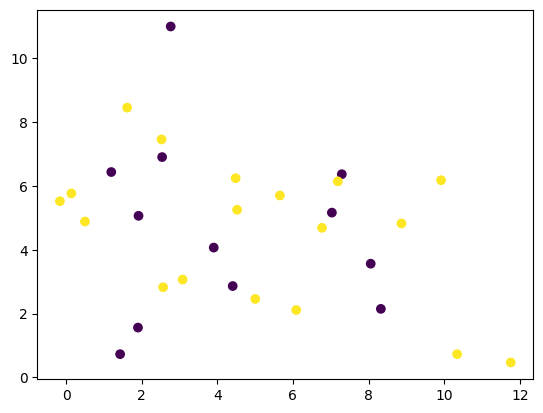

In [12]:
# Generate random Gaussian data with mean 5 and stdev 3 in both x and y
rng = np.random.default_rng()
x_r = rng.normal(loc=5, scale=3, size=(30,))
y_r = rng.normal(loc=5, scale=3, size=(30,))

# Very useful for this class: if you want to color-code
# scatter plot values, use the c= optional paramerer of plt.scatter
# TODO: Generate random integer values, make colored scatter plot below
color_code = rng.integers(low=0, high=2, size=30)
plt.scatter(x_r, y_r, c=color_code)
plt.show()

## 3: pandas

**Remember:** pandas holds 2D table data and works like your CS251/CS252 `Data` class.

In [13]:
import pandas as pd

### Load data with `read_csv`

Let's load in fMRI data in CSV format that is located in the data folder within the working directory


- `head()` method shows us the first few rows of the data
- `tail()` method shows us the last few rows of the data

In [14]:
ds = pd.read_csv('data/fmri.csv')
ds.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


If the CSV file doesn't have headers, the import can look wonky:

In [15]:
ds = pd.read_csv('data/fmri_no_headers.csv')
ds.head()

,s13,18,stim,parietal,-0.017551581538
0,s5,14,stim,parietal,-0.080883
1,s12,18,stim,parietal,-0.081033
2,s11,18,stim,parietal,-0.046134
3,s10,18,stim,parietal,-0.037970
4,s9,18,stim,parietal,-0.103513


We can fix that with the `header=None` optional argument. We can also give it a list of custom headers with `names` 

(e.g. `['F1', 'F2', 'F3', 'F4', 'F5']`)

In [ ]:
# ds = pd.read_csv('data/fmri_no_headers.csv', header=None)
ds = pd.read_csv('data/fmri_no_headers.csv', header=None, names=['F1', 'F2', 'F3', 'F4', 'F5'])
ds.head()

,F1,F2,F3,F4,F5
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


**NOTE:** We can give `read_csv` a URL string of the CSV file from the internet and it will automatically download and load it in for us!


- `read_csv` has lots of optional parameters to handle stuff like skipping the first N rows of data (if there's metadata), using a non-comma delimiter, etc. Check out the massive documentation page: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

### Convert categorical feature to int-coded feature

Let's take the categorical (string) feature `region` and map it to an int-code (0->frontal, 1->parietal)

In [17]:
ds = pd.read_csv('data/fmri.csv')
ds.head()
# Convert region to categorical data type
ds['region'] = pd.Categorical(ds['region'])
ds['region']

# replace strings with their int categorical codes
ds['region'] = ds['region'].cat.codes
ds.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,1,-0.017552
1,s5,14,stim,1,-0.080883
2,s12,18,stim,1,-0.081033
3,s11,18,stim,1,-0.046134
4,s10,18,stim,1,-0.037970


### Convert `pandas DataFrame` -> numpy array

Convert entire `DataFrame`

In [18]:
ds_arr = ds.to_numpy()
ds_arr

array([['s13', 18, 'stim', 1, -0.017551581538],
       ['s5', 14, 'stim', 1, -0.0808829319505],
       ['s12', 18, 'stim', 1, -0.0810330187333],
       ...,
       ['s12', 7, 'cue', 0, -0.00493910613621],
       ['s11', 7, 'cue', 0, -0.0253667098182],
       ['s0', 0, 'cue', 1, -0.00689923478092]],
      shape=(1064, 5), dtype=object)

#### or easily export the `DataFrame`  as a csv file

In [ ]:
ds.to_csv('data/test_out.csv', index=False)